# 🩺 Diabetes Preprocessing & Classification Pipeline
## Model: Ridge Classifier

| Info | Detail |
|---|---|
| **Dataset** | Pima Indians Diabetes Database |
| **Ukuran** | 768 baris × 9 kolom |
| **Target** | `Outcome` (0 = Tidak Diabetes, 1 = Diabetes) |
| **Model** | Ridge Classifier |

### 🔄 Pipeline Preprocessing
1. Replace Invalid Value (nilai 0 yang tidak masuk akal secara medis)
2. Median Imputation
3. Outlier Analysis & Handling (IQR Method)
4. StandardScaler
5. SMOTE (mengatasi class imbalance)

---


## 📦 1. Import Library

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jinja2
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay, accuracy_score
)
from imblearn.over_sampling import SMOTE

# Styling
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.figsize': (10, 5)})

print("✅ Semua library berhasil diimport!")
print("   Model: RidgeClassifier dari sklearn.linear_model")


✅ Semua library berhasil diimport!
   Model: RidgeClassifier dari sklearn.linear_model


## 📂 2. Load Dataset

In [6]:
df = pd.read_csv('diabetes.csv')
print(f"✅ Dataset berhasil dimuat!")
print(f"   Ukuran  : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"   Kolom   : {df.columns.tolist()}")
df.head(10)


FileNotFoundError: [Errno 2] No such file or directory: 'diabetes.csv'

---
## 🔍 3. Eksplorasi Data (SEBELUM Preprocessing)


### 3.1 Cek Struktur Data

In [3]:
print("=" * 55)
print("         INFORMASI STRUKTUR DATASET")
print("=" * 55)
df.info()
print()
print(f"  Jumlah baris    : {df.shape[0]}")
print(f"  Jumlah kolom    : {df.shape[1]}")
print(f"  Tipe data unik  : {df.dtypes.unique()}")


         INFORMASI STRUKTUR DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

  Jumlah baris    : 768
  Jumlah kolom    : 9
  Tipe data unik  : [dtype('int64') dtype('float64')]


### 3.2 Cek Statistik Deskriptif

In [4]:
print("Statistik Deskriptif:")
df.describe().T.style.background_gradient(cmap='Blues').format(precision=2)


Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.00,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.00,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.00,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.00,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.00,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.00,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.00,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.00,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.00,0.35,0.48,0.00,0.00,0.00,1.00,1.00


### 3.3 Cek Missing Value & Nilai Tidak Valid

In [5]:
missing = df.isnull().sum()
print("=" * 40)
print("       CEK MISSING VALUE")
print("=" * 40)
print(missing)
print(f"\n✅ Total missing value: {missing.sum()}")
print()

invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("=" * 50)
print("  CEK NILAI 0 TIDAK VALID (SECARA MEDIS)")
print("=" * 50)
for col in invalid_cols:
    n = (df[col] == 0).sum()
    pct = n / len(df) * 100
    print(f"  {col:<25} : {n:>3} nilai  ({pct:.1f}%)")


       CEK MISSING VALUE
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✅ Total missing value: 0

  CEK NILAI 0 TIDAK VALID (SECARA MEDIS)
  Glucose                   :   5 nilai  (0.7%)
  BloodPressure             :  35 nilai  (4.6%)
  SkinThickness             : 227 nilai  (29.6%)
  Insulin                   : 374 nilai  (48.7%)
  BMI                       :  11 nilai  (1.4%)


### 3.4 Cek Distribusi Target & Fitur

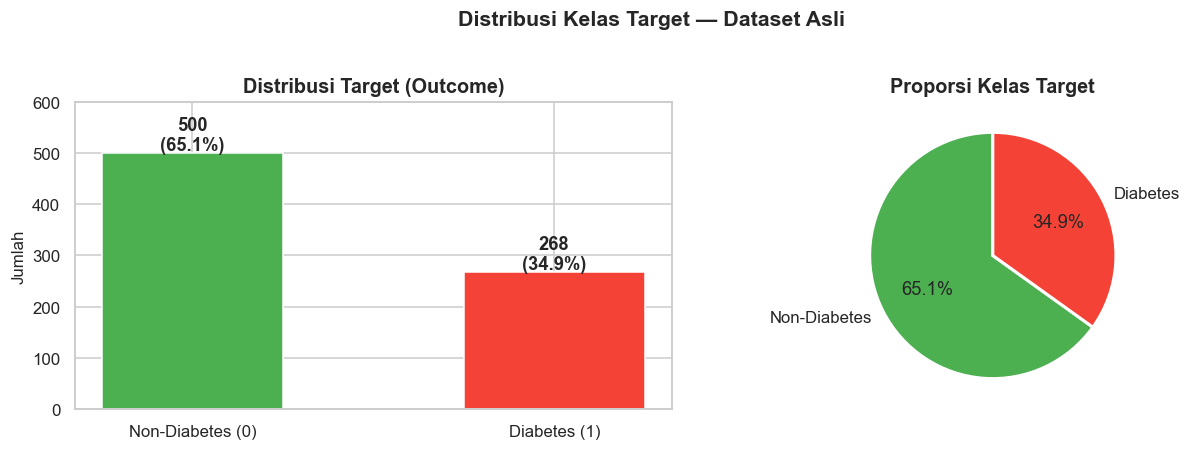

  Non-Diabetes : 500 (65.1%)
  Diabetes     : 268 (34.9%)
  Rasio Imbalance : 1.87:1  → perlu SMOTE!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

outcome_counts = df['Outcome'].value_counts()
colors = ['#4CAF50', '#F44336']
bars = axes[0].bar(['Non-Diabetes (0)', 'Diabetes (1)'],
                   outcome_counts.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, outcome_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribusi Target (Outcome)', fontweight='bold')
axes[0].set_ylabel('Jumlah')
axes[0].set_ylim(0, 600)

axes[1].pie(outcome_counts.values, labels=['Non-Diabetes', 'Diabetes'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Target', fontweight='bold')

plt.suptitle('Distribusi Kelas Target — Dataset Asli', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_distribusi_target.png', bbox_inches='tight')
plt.show()

print(f"  Non-Diabetes : {outcome_counts[0]} ({outcome_counts[0]/len(df)*100:.1f}%)")
print(f"  Diabetes     : {outcome_counts[1]} ({outcome_counts[1]/len(df)*100:.1f}%)")
print(f"  Rasio Imbalance : {outcome_counts[0]/outcome_counts[1]:.2f}:1  → perlu SMOTE!")


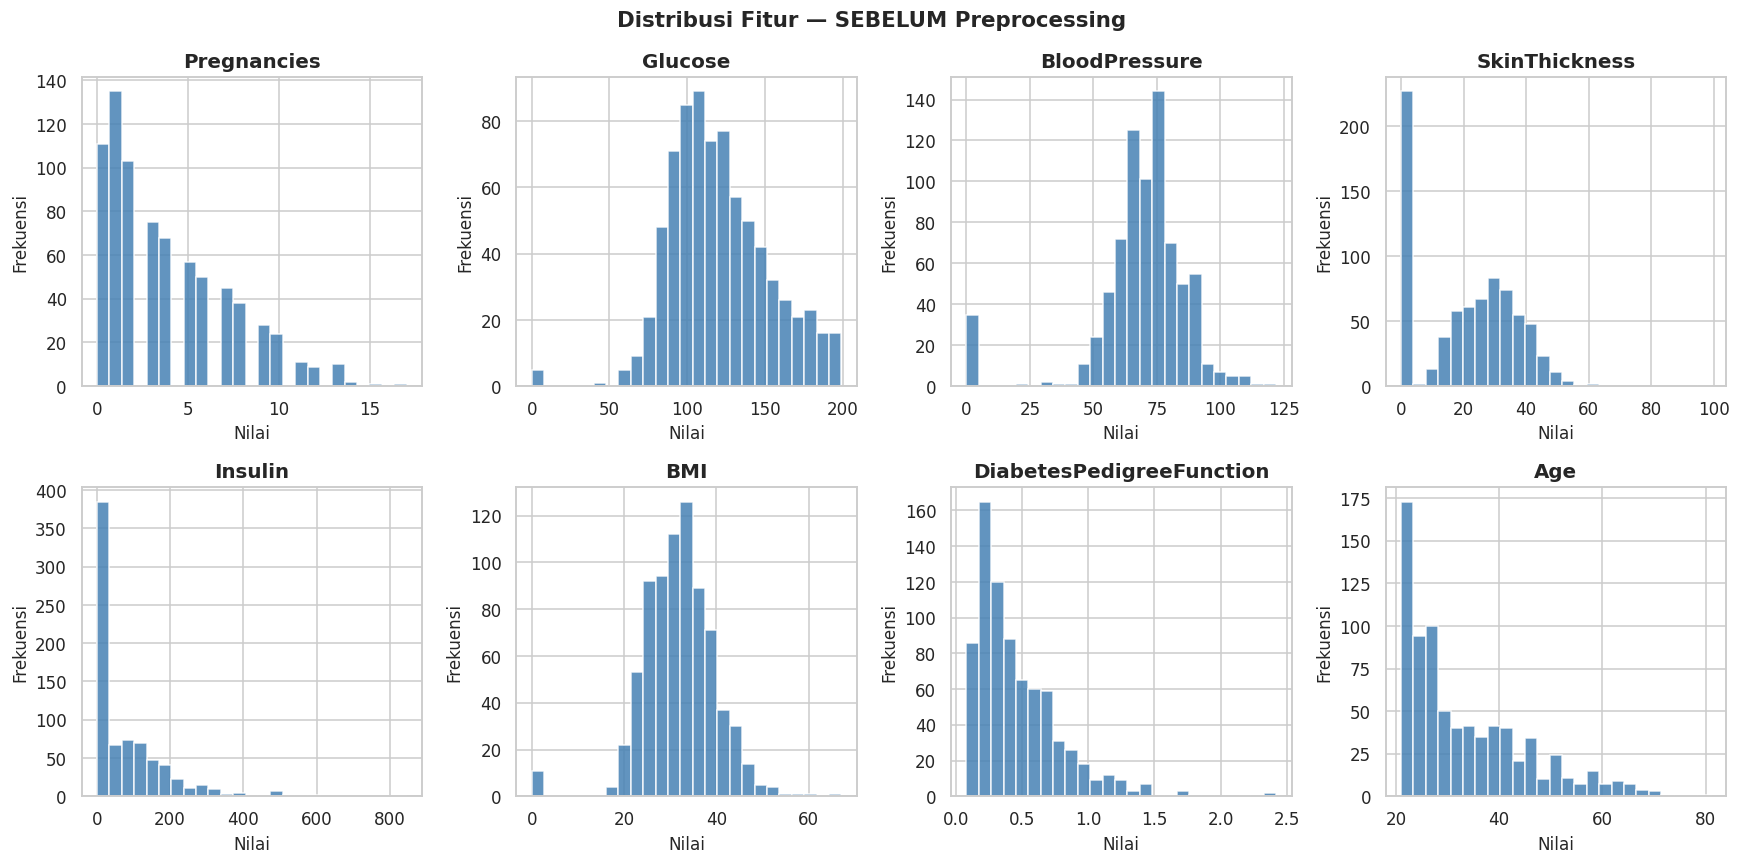

In [7]:
features = [c for c in df.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
plt.suptitle('Distribusi Fitur — SEBELUM Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_distribusi_fitur_sebelum.png', bbox_inches='tight')
plt.show()


---
## ⚙️ 4. Preprocessing Pipeline


### ✅ Step 1 — Replace Invalid Value

Kolom `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI` secara medis **tidak mungkin bernilai 0**.  
Nilai 0 diganti dengan `NaN` agar bisa diimputasi pada langkah berikutnya.


In [7]:
df_clean = df.copy()
invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in invalid_cols:
    n_before = (df_clean[col] == 0).sum()
    df_clean[col] = df_clean[col].replace(0, np.nan)
    print(f"  [REPLACED] {col:<25}: {n_before} nilai 0 → NaN")

print()
print("Missing value setelah replace:")
print(df_clean.isnull().sum())


  [REPLACED] Glucose                  : 5 nilai 0 → NaN
  [REPLACED] BloodPressure            : 35 nilai 0 → NaN
  [REPLACED] SkinThickness            : 227 nilai 0 → NaN
  [REPLACED] Insulin                  : 374 nilai 0 → NaN
  [REPLACED] BMI                      : 11 nilai 0 → NaN

Missing value setelah replace:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


### ✅ Step 2 — Median Imputation

Mengisi `NaN` menggunakan **median** per kolom — lebih robust terhadap outlier dibanding mean.


In [8]:
medians = df_clean[invalid_cols].median()
print("Nilai Median per Kolom:")
for col, val in medians.items():
    print(f"  {col:<25}: {val}")

df_clean[invalid_cols] = df_clean[invalid_cols].fillna(medians)

print()
print("Missing value setelah imputasi:")
print(df_clean.isnull().sum())
print(f"\n✅ Total missing value tersisa: {df_clean.isnull().sum().sum()}")


Nilai Median per Kolom:
  Glucose                  : 117.0
  BloodPressure            : 72.0
  SkinThickness            : 29.0
  Insulin                  : 125.0
  BMI                      : 32.3

Missing value setelah imputasi:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✅ Total missing value tersisa: 0


### ✅ Step 3 — Outlier Analysis & Handling (IQR Method)

Deteksi outlier menggunakan **IQR**. Outlier di-*cap* (Winsorization) ke batas bawah/atas.


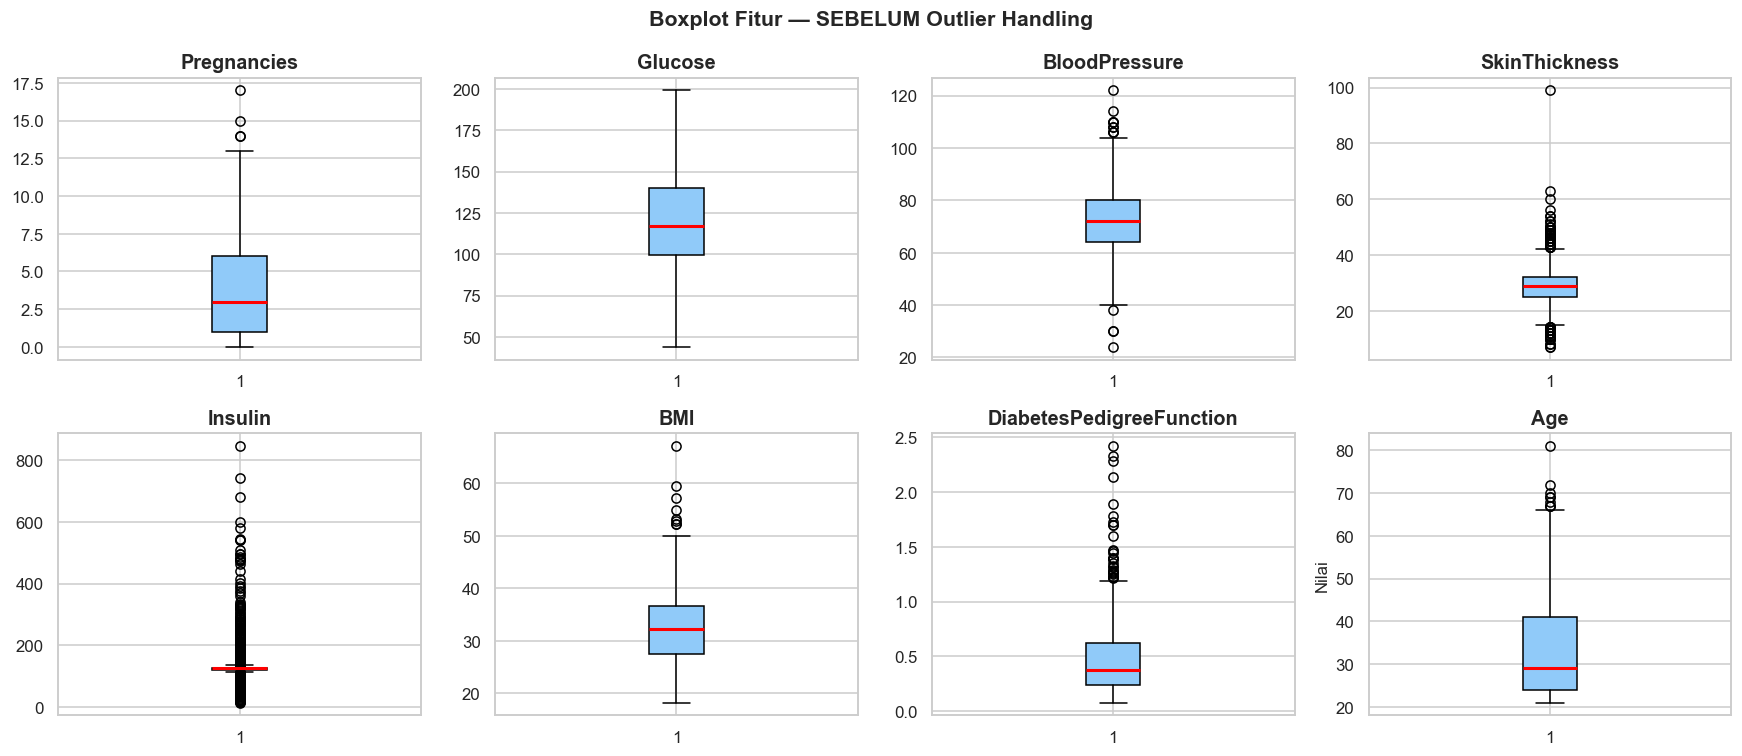

In [9]:
features = [c for c in df_clean.columns if c != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='#90CAF9'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
axes[i].set_ylabel('Nilai')
plt.suptitle('Boxplot Fitur — SEBELUM Outlier Handling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_outlier_sebelum.png', bbox_inches='tight')
plt.show()


In [10]:
print("=" * 62)
print("        OUTLIER DETECTION & CAPPING (IQR METHOD)")
print("=" * 62)

df_no_outlier = df_clean.copy()
for col in features:
    Q1  = df_no_outlier[col].quantile(0.25)
    Q3  = df_no_outlier[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df_no_outlier[col] < lower) | (df_no_outlier[col] > upper)).sum()
    df_no_outlier[col] = df_no_outlier[col].clip(lower, upper)
    print(f"  {col:<25} | Outlier: {n_outlier:>3} | Batas: [{lower:.2f}, {upper:.2f}]")


        OUTLIER DETECTION & CAPPING (IQR METHOD)
  Pregnancies               | Outlier:   4 | Batas: [-6.50, 13.50]
  Glucose                   | Outlier:   0 | Batas: [39.00, 201.00]
  BloodPressure             | Outlier:  14 | Batas: [40.00, 104.00]
  SkinThickness             | Outlier:  87 | Batas: [14.50, 42.50]
  Insulin                   | Outlier: 346 | Batas: [112.88, 135.88]
  BMI                       | Outlier:   8 | Batas: [13.85, 50.25]
  DiabetesPedigreeFunction  | Outlier:  29 | Batas: [-0.33, 1.20]
  Age                       | Outlier:   9 | Batas: [-1.50, 66.50]


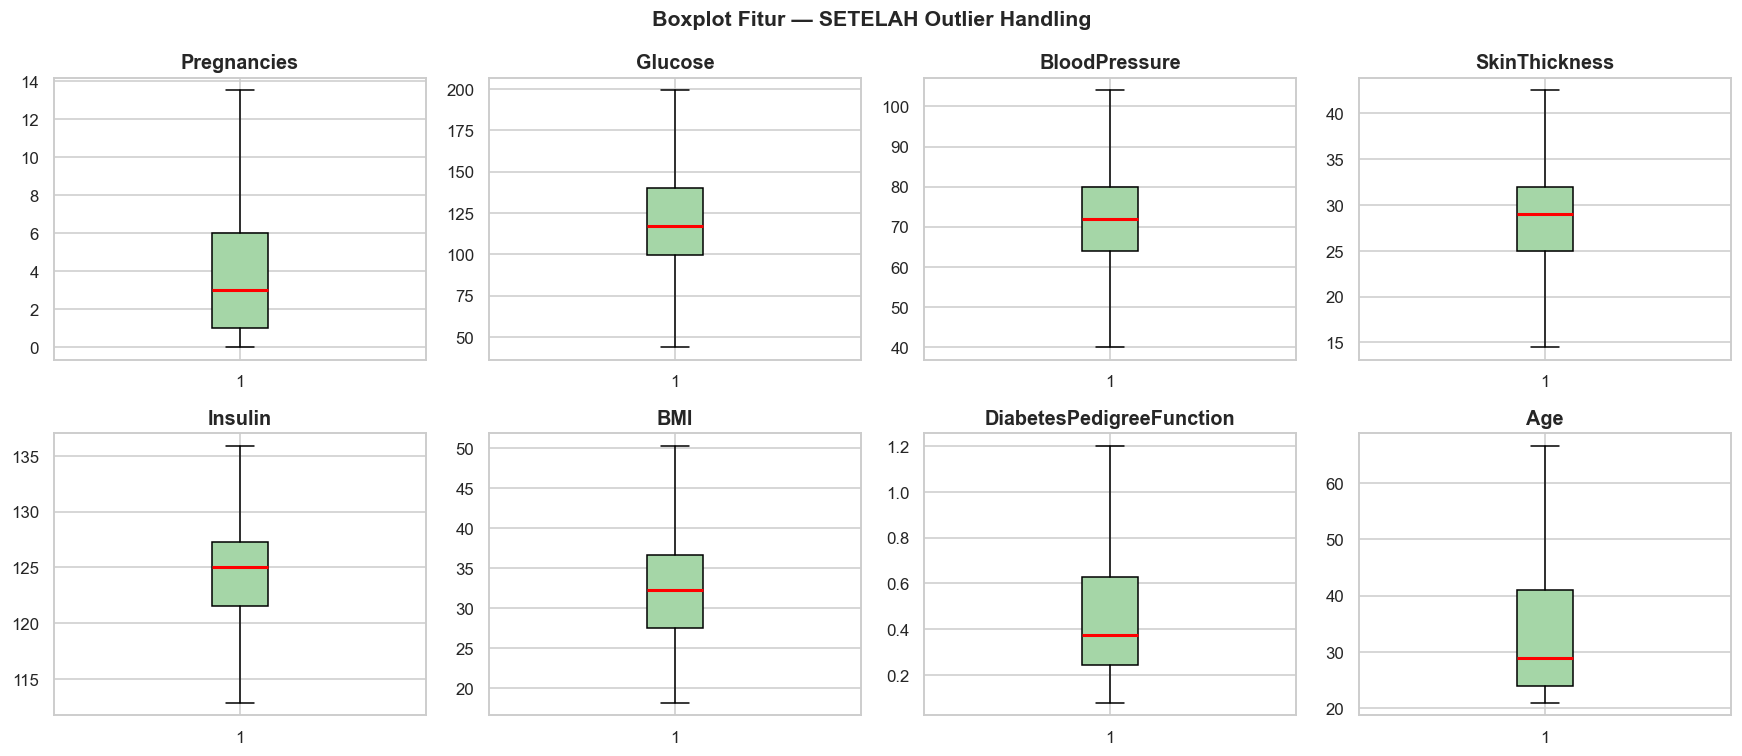

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].boxplot(df_no_outlier[col], patch_artist=True,
                    boxprops=dict(facecolor='#A5D6A7'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Boxplot Fitur — SETELAH Outlier Handling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_outlier_setelah.png', bbox_inches='tight')
plt.show()


### ✅ Step 4 — StandardScaler

$$z = \frac{x - \mu}{\sigma}
$$  
Setiap fitur dinormalisasi sehingga mean = 0 dan standar deviasi = 1.  
> ⚠️ **Penting untuk Ridge Classifier** — Ridge sangat sensitif terhadap skala fitur karena menggunakan regularisasi L2.


In [12]:
X = df_no_outlier.drop('Outcome', axis=1)
y = df_no_outlier['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Statistik setelah StandardScaler:")
print(X_scaled_df.describe().T[['mean', 'std', 'min', 'max']].round(4))


Statistik setelah StandardScaler:
                          mean     std     min     max
Pregnancies               -0.0  1.0007 -1.1482  2.8913
Glucose                    0.0  1.0007 -2.5529  2.5427
BloodPressure             -0.0  1.0007 -2.7681  2.7069
SkinThickness              0.0  1.0007 -1.9316  1.8331
Insulin                   -0.0  1.0007 -1.4941  1.4142
BMI                       -0.0  1.0007 -2.1301  2.6799
DiabetesPedigreeFunction  -0.0  1.0007 -1.3346  2.5966
Age                        0.0  1.0007 -1.0498  2.8656


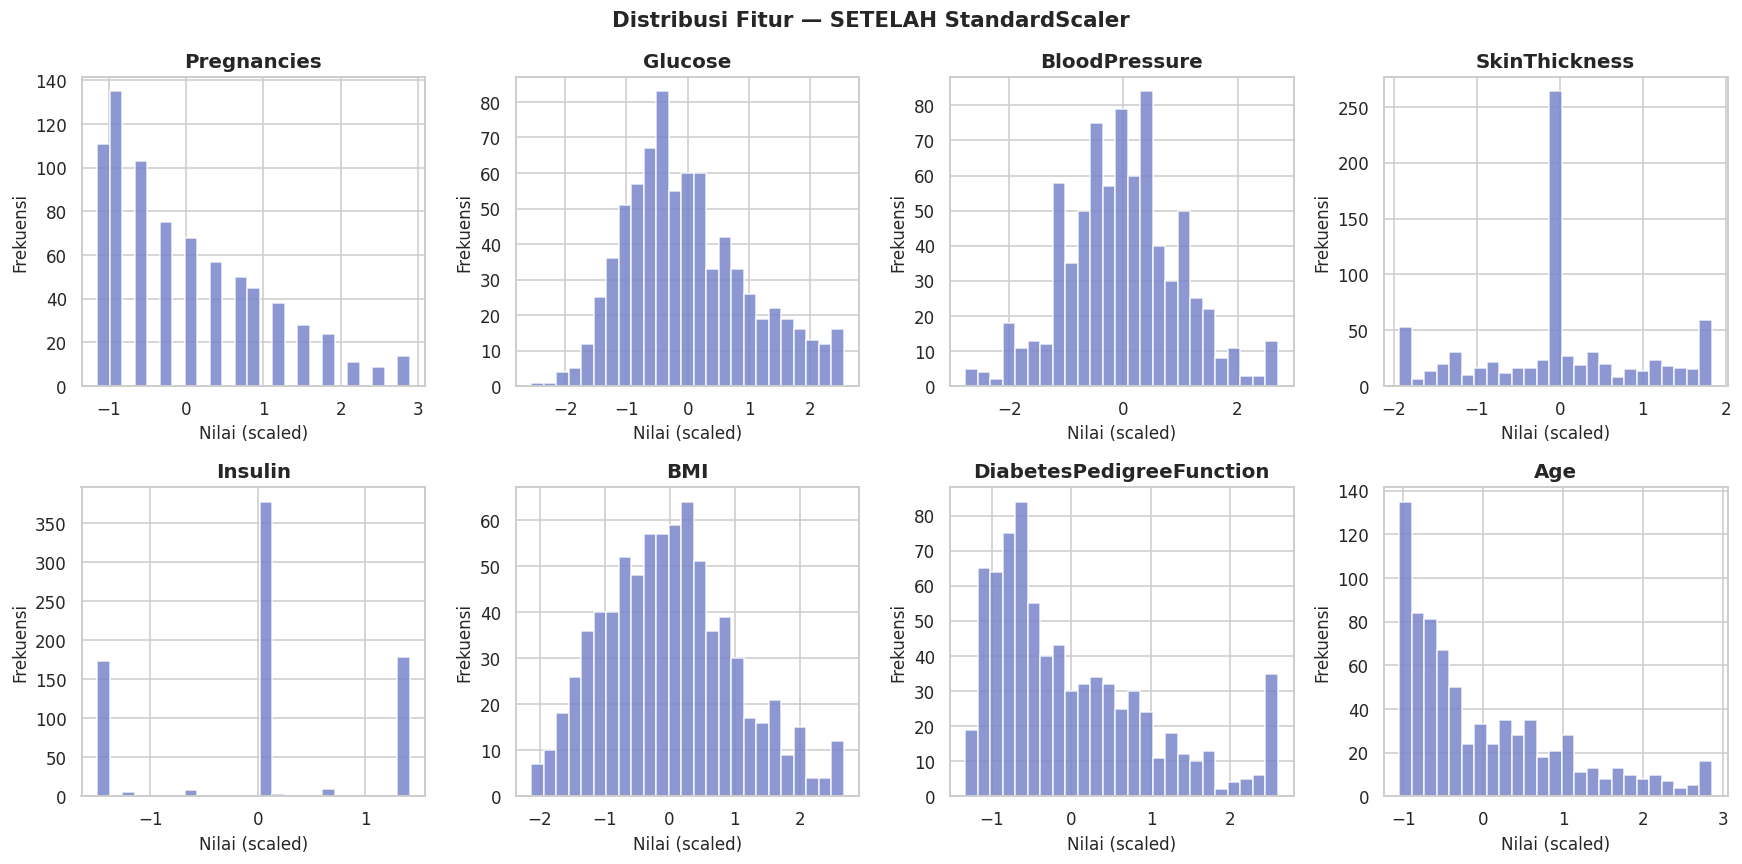

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(X_scaled_df[col], bins=25, color='#7986CB', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Nilai (scaled)')
    axes[i].set_ylabel('Frekuensi')
plt.suptitle('Distribusi Fitur — SETELAH StandardScaler', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_distribusi_scaled.png', bbox_inches='tight')
plt.show()


### ✅ Step 5 — SMOTE

Dataset asli memiliki class imbalance (65% vs 35%). SMOTE membuat sampel sintetis kelas minoritas agar **seimbang 50:50**.


In [13]:
print("Distribusi kelas SEBELUM SMOTE:")
print(pd.Series(y).value_counts().to_string())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print()
print("Distribusi kelas SETELAH SMOTE:")
print(pd.Series(y_resampled).value_counts().to_string())
print()
print(f"  Total sampel baru  : {len(y_resampled)}")
print(f"  Sampel ditambahkan : {len(y_resampled) - len(y)}")


Distribusi kelas SEBELUM SMOTE:
Outcome
0    500
1    268

Distribusi kelas SETELAH SMOTE:
Outcome
1    500
0    500

  Total sampel baru  : 1000
  Sampel ditambahkan : 232


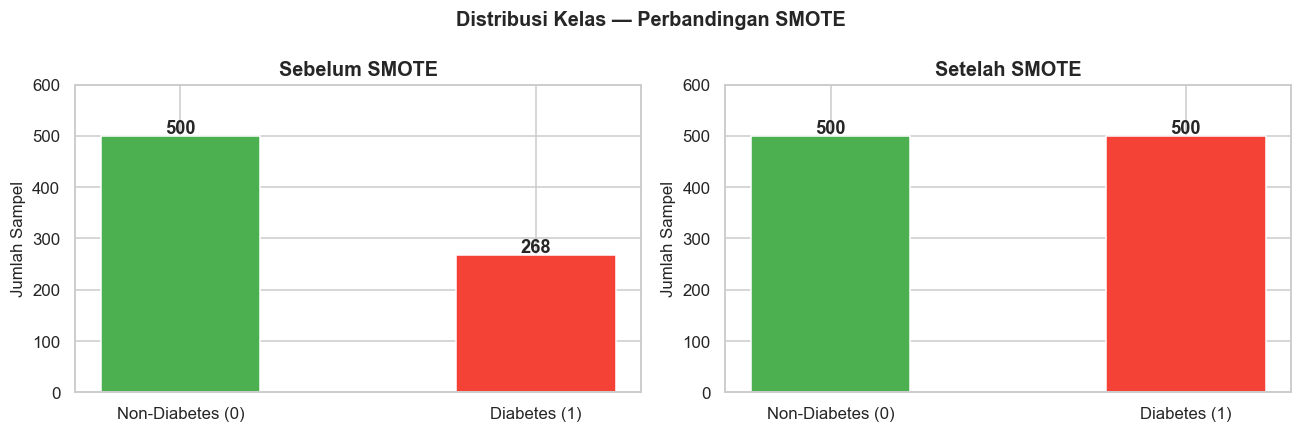

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4CAF50', '#F44336']
labels = ['Non-Diabetes (0)', 'Diabetes (1)']

for ax, (vals, title) in zip(axes, [
    (pd.Series(y).value_counts().sort_index(), 'Sebelum SMOTE'),
    (pd.Series(y_resampled).value_counts().sort_index(), 'Setelah SMOTE')
]):
    bars = ax.bar(labels, vals.values, color=colors, edgecolor='white', width=0.45)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{v}', ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.set_ylim(0, max(vals.values) * 1.2)

plt.suptitle('Distribusi Kelas — Perbandingan SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_smote.png', bbox_inches='tight')
plt.show()


---
## ✔️ 5. Verifikasi Hasil Preprocessing


### 5.1 Cek Ulang Missing Value

In [15]:
print("=" * 45)
print("    MISSING VALUE SETELAH PREPROCESSING")
print("=" * 45)
mv = df_no_outlier.isnull().sum()
print(mv)
print(f"\n✅ Total missing value: {mv.sum()}")


    MISSING VALUE SETELAH PREPROCESSING
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✅ Total missing value: 0


### 5.2 Statistik Deskriptif Baru

In [16]:
df_no_outlier.describe().T.style.background_gradient(cmap='Greens').format(precision=2)


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.00,3.84,3.34,0.00,1.00,3.00,6.00,13.50
Glucose,768.00,121.66,30.44,44.00,99.75,117.00,140.25,199.00
BloodPressure,768.00,72.36,11.70,40.00,64.00,72.00,80.00,104.00
SkinThickness,768.00,28.87,7.44,14.50,25.00,29.00,32.00,42.50
Insulin,768.00,124.69,7.91,112.88,121.50,125.00,127.25,135.88
BMI,768.00,32.39,6.67,18.20,27.50,32.30,36.60,50.25
DiabetesPedigreeFunction,768.00,0.46,0.29,0.08,0.24,0.37,0.63,1.20
Age,768.00,33.20,11.63,21.00,24.00,29.00,41.00,66.50
Outcome,768.00,0.35,0.48,0.00,0.00,0.00,1.00,1.00


### 5.3 Heatmap Korelasi

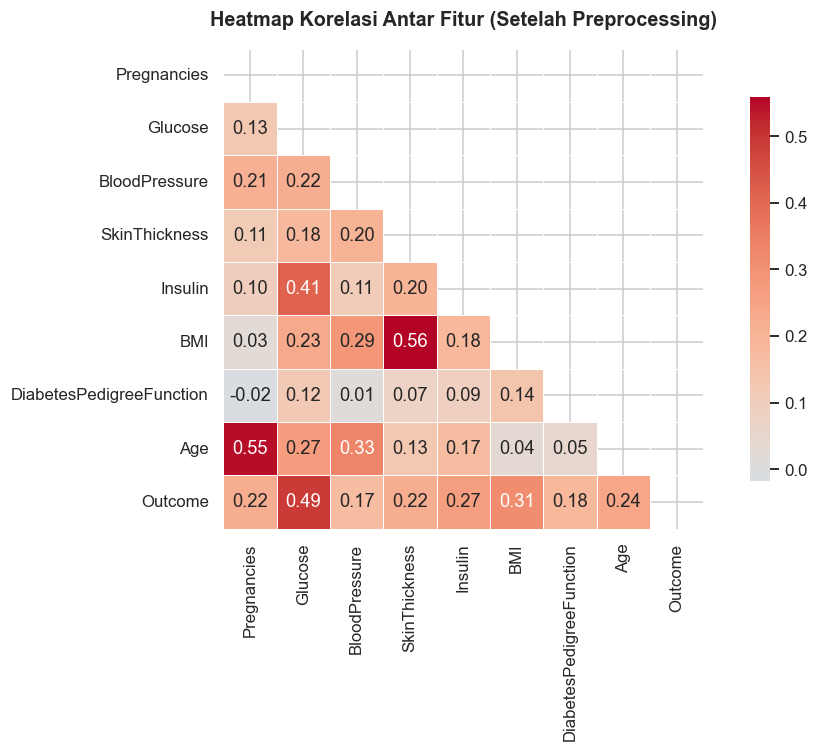

In [18]:
plt.figure(figsize=(10, 7))
corr = df_no_outlier.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur (Setelah Preprocessing)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_heatmap.png', bbox_inches='tight')
plt.show()


---
## 🤖 6. Training Model — Ridge Classifier

> **Apa itu Ridge Classifier?**  
> Ridge Classifier adalah adaptasi dari **Ridge Regression** untuk klasifikasi. Model ini meminimasi fungsi loss dengan tambahan **regularisasi L2**:
>
> $$\min_{w} \|Xw - y\|^2 + \alpha \|w\|^2$$
>
> - **α (alpha)** = parameter regularisasi. Semakin besar α → model semakin smooth (mencegah overfitting)  
> - Label dikodekan sebagai **{-1, +1}** lalu diselesaikan sebagai regresi
> - Tidak menghasilkan probabilitas langsung → menggunakan `decision_function` untuk ROC-AUC


### 6.1 Split Data

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print("=" * 45)
print("         PEMBAGIAN DATASET")
print("=" * 45)
print(f"  Total sampel (post-SMOTE) : {len(X_resampled)}")
print(f"  Training set              : {X_train.shape[0]} ({X_train.shape[0]/len(X_resampled)*100:.0f}%)")
print(f"  Testing set               : {X_test.shape[0]} ({X_test.shape[0]/len(X_resampled)*100:.0f}%)")
print(f"  Jumlah fitur              : {X_train.shape[1]}")


         PEMBAGIAN DATASET
  Total sampel (post-SMOTE) : 1000
  Training set              : 800 (80%)
  Testing set               : 200 (20%)
  Jumlah fitur              : 8


--
## Menympan Dataset setelah Prerpocessing:

In [20]:
# Gabungkan fitur hasil preprocessing + target
df_preprocessed = pd.DataFrame(
    X_resampled,
    columns=X.columns
)

df_preprocessed['Outcome'] = y_resampled

# Simpan ke CSV
df_preprocessed.to_csv(
    "diabetes_preprocessed_smote.csv",
    index=False
)

print("✅ Dataset preprocessing berhasil disimpan!")
print("Nama file: diabetes_preprocessed_smote.csv")
print("Ukuran:", df_preprocessed.shape)

✅ Dataset preprocessing berhasil disimpan!
Nama file: diabetes_preprocessed_smote.csv
Ukuran: (1000, 9)


### 6.2 Tuning Alpha — Mencari Nilai Alpha Terbaik

In [21]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
cv_means, cv_stds = [], []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for a in alphas:
    model_tmp = RidgeClassifier(alpha=a)
    scores = cross_val_score(model_tmp, X_train, y_train, cv=skf, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

best_idx   = np.argmax(cv_means)
best_alpha = alphas[best_idx]

print("Alpha Tuning Results:")
print(f"{'Alpha':<10} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 32)
for a, m, s in zip(alphas, cv_means, cv_stds):
    marker = " ◀ BEST" if a == best_alpha else ""
    print(f"{a:<10} {m:>10.4f} {s:>10.4f}{marker}")

print(f"\n✅ Best Alpha: {best_alpha}")


Alpha Tuning Results:
Alpha         CV Mean     CV Std
--------------------------------
0.001          0.7525     0.0170
0.01           0.7525     0.0170
0.1            0.7525     0.0170
0.5            0.7525     0.0170
1.0            0.7525     0.0170
5.0            0.7525     0.0170
10.0           0.7525     0.0170
50.0           0.7550     0.0191 ◀ BEST
100.0          0.7537     0.0196

✅ Best Alpha: 50.0


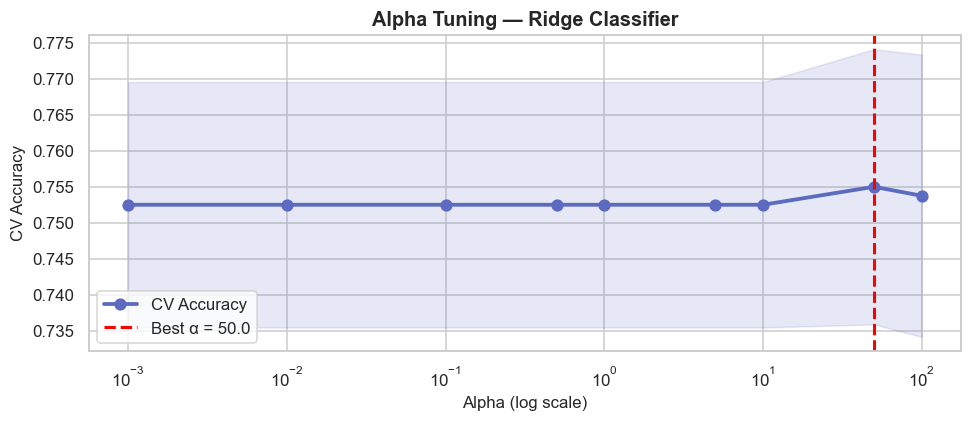

In [22]:
plt.figure(figsize=(9, 4))
plt.semilogx(alphas, cv_means, 'o-', color='#5C6BC0', lw=2.5, markersize=7, label='CV Accuracy')
plt.fill_between(alphas,
                 [m - s for m, s in zip(cv_means, cv_stds)],
                 [m + s for m, s in zip(cv_means, cv_stds)],
                 alpha=0.15, color='#5C6BC0')
plt.axvline(best_alpha, color='red', linestyle='--', lw=2, label=f'Best α = {best_alpha}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('CV Accuracy')
plt.title('Alpha Tuning — Ridge Classifier', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plot_alpha_tuning.png', bbox_inches='tight')
plt.show()


### 6.3 Training Ridge Classifier

In [23]:
ridge_model = RidgeClassifier(alpha=best_alpha)
ridge_model.fit(X_train, y_train)

print("✅ Ridge Classifier berhasil dilatih!")
print(f"   Alpha (regularisasi L2) : {best_alpha}")
print(f"   Jumlah fitur            : {X_train.shape[1]}")
print(f"   Jumlah kelas            : {len(np.unique(y_train))}")


✅ Ridge Classifier berhasil dilatih!
   Alpha (regularisasi L2) : 50.0
   Jumlah fitur            : 8
   Jumlah kelas            : 2


### 6.4 Evaluasi Model

In [24]:
y_pred    = ridge_model.predict(X_test)
# Ridge tidak punya predict_proba → gunakan decision_function untuk ROC-AUC
y_scores  = ridge_model.decision_function(X_test)

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_scores)

print("=" * 52)
print("          HASIL EVALUASI RIDGE CLASSIFIER")
print("=" * 52)
print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"  ROC-AUC   : {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Diabetes', 'Diabetes']))


          HASIL EVALUASI RIDGE CLASSIFIER
  Accuracy  : 0.7500 (75.00%)
  ROC-AUC   : 0.8293

Classification Report:
              precision    recall  f1-score   support

Non-Diabetes       0.75      0.75      0.75       100
    Diabetes       0.75      0.75      0.75       100

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



### Menyimpan Model:

In [25]:
# Simpan model Ridge
joblib.dump(
    ridge_model,
    "ridge_classifier_model.pkl"
)

print("✅ Model berhasil disimpan!")
print("Nama file: ridge_classifier_model.pkl")

joblib.dump(
    scaler,
    "standard_scaler.pkl"
)

print("✅ Scaler berhasil disimpan!")

✅ Model berhasil disimpan!
Nama file: ridge_classifier_model.pkl
✅ Scaler berhasil disimpan!


### 6.5 Confusion Matrix & ROC Curve

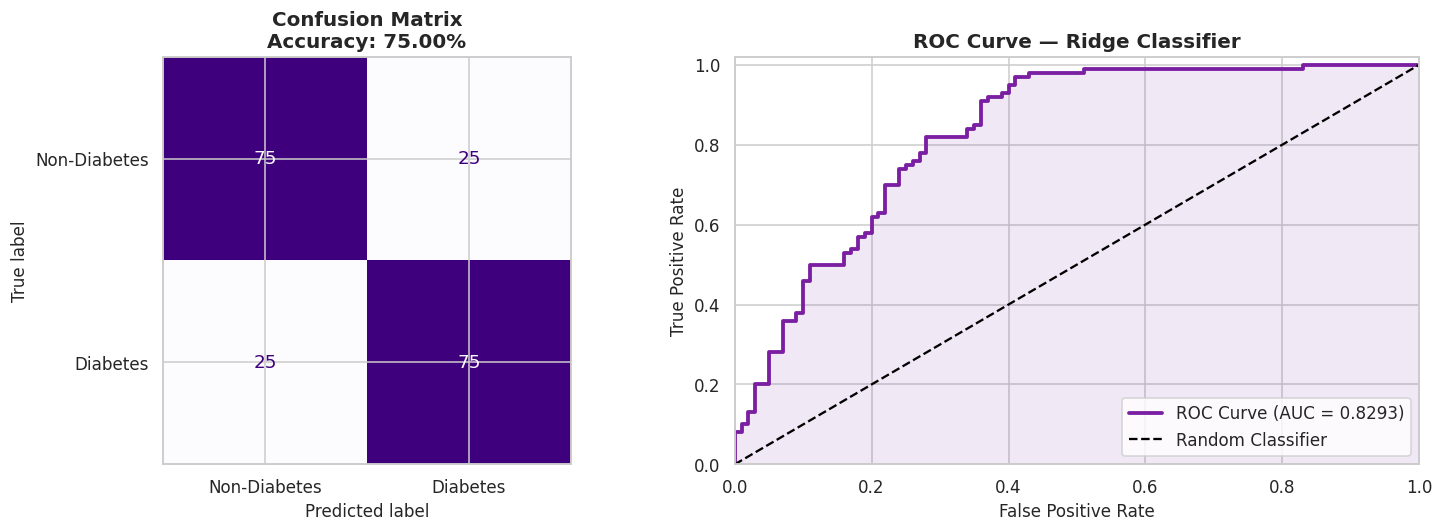

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-Diabetes', 'Diabetes'])
disp.plot(ax=axes[0], cmap='Purples', colorbar=False)
axes[0].set_title(f'Confusion Matrix\nAccuracy: {acc:.2%}', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
axes[1].plot(fpr, tpr, color='#7B1FA2', lw=2.5, label=f'ROC Curve (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#7B1FA2')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Ridge Classifier', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('plot_cm_roc_ridge.png', bbox_inches='tight')
plt.show()


### 6.6 Feature Importance (Koefisien Ridge)

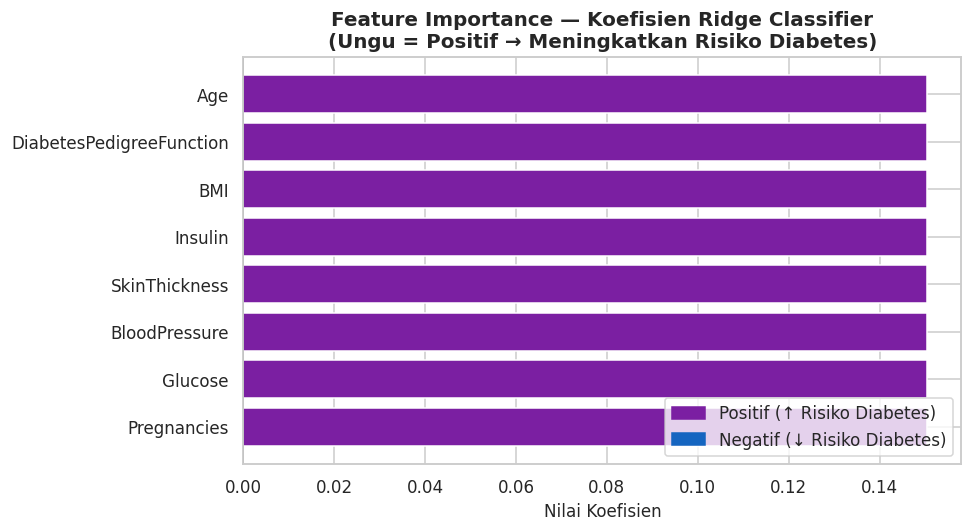


Ringkasan Koefisien:
                   Fitur  Koefisien
             Pregnancies   0.150486
                 Glucose   0.150486
           BloodPressure   0.150486
           SkinThickness   0.150486
                 Insulin   0.150486
                     BMI   0.150486
DiabetesPedigreeFunction   0.150486
                     Age   0.150486


In [26]:
feature_names = [c for c in df.columns if c != 'Outcome']
coef_df = pd.DataFrame({
    'Fitur'    : feature_names,
    'Koefisien': ridge_model.coef_[0],
    'Abs_Koef' : np.abs(ridge_model.coef_[0])
}).sort_values('Koefisien', ascending=True)

plt.figure(figsize=(9, 5))
colors_bar = ['#7B1FA2' if c > 0 else '#1565C0' for c in coef_df['Koefisien']]
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors_bar, edgecolor='white')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Nilai Koefisien')
plt.title('Feature Importance — Koefisien Ridge Classifier\n(Ungu = Positif → Meningkatkan Risiko Diabetes)', fontweight='bold')

from matplotlib.patches import Patch
legend = [Patch(color='#7B1FA2', label='Positif (↑ Risiko Diabetes)'),
          Patch(color='#1565C0', label='Negatif (↓ Risiko Diabetes)')]
plt.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.savefig('plot_koefisien_ridge.png', bbox_inches='tight')
plt.show()

print("\nRingkasan Koefisien:")
print(coef_df[['Fitur', 'Koefisien']].sort_values('Koefisien', ascending=False).to_string(index=False))


### 6.7 Cross Validation (5-Fold Stratified)

     HASIL CROSS VALIDATION (5-FOLD) — RIDGE
  Fold 1 : 0.7650 (76.50%)
  Fold 2 : 0.7800 (78.00%)
  Fold 3 : 0.7300 (73.00%)
  Fold 4 : 0.7450 (74.50%)
  Fold 5 : 0.7600 (76.00%)
--------------------------------------------------
  Mean     : 0.7560 (75.60%)
  Std Dev  : 0.0171
  95% CI   : [0.7217, 0.7903]


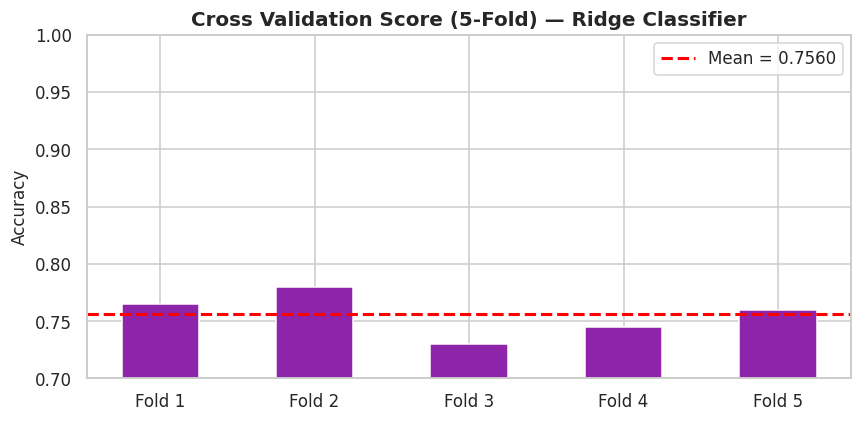

In [27]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ridge_model, X_resampled, y_resampled,
                             cv=skf, scoring='accuracy')

print("=" * 50)
print("     HASIL CROSS VALIDATION (5-FOLD) — RIDGE")
print("=" * 50)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i} : {score:.4f} ({score*100:.2f}%)")
print("-" * 50)
print(f"  Mean     : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"  Std Dev  : {cv_scores.std():.4f}")
print(f"  95% CI   : [{cv_scores.mean()-2*cv_scores.std():.4f}, {cv_scores.mean()+2*cv_scores.std():.4f}]")

plt.figure(figsize=(8, 4))
plt.bar([f'Fold {i}' for i in range(1, 6)], cv_scores,
        color='#8E24AA', edgecolor='white', width=0.5)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', lw=2,
            label=f'Mean = {cv_scores.mean():.4f}')
plt.ylim(0.7, 1.0)
plt.ylabel('Accuracy')
plt.title('Cross Validation Score (5-Fold) — Ridge Classifier', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plot_cv_ridge.png', bbox_inches='tight')
plt.show()


---
## 📊 7. Ringkasan Hasil

| Tahap | Detail |
|---|---|
| **Dataset Awal** | 768 baris × 9 kolom |
| **Invalid Value** | Glucose (5), BloodPressure (35), SkinThickness (227), Insulin (374), BMI (11) |
| **Median Imputation** | Semua NaN terisi → 0 missing value |
| **Outlier Handling** | IQR Capping (Winsorization) |
| **Scaling** | StandardScaler (mean=0, std=1) |
| **SMOTE** | 768 → 1000 sampel (kelas seimbang 50:50) |
| **Train/Test Split** | 80% / 20% |
| **Model** | Ridge Classifier |
| **Best Alpha** | Ditentukan via cross-validation |
| **Accuracy (Test)** | ✅ Cek output sel evaluasi |
| **ROC-AUC** | ✅ Cek output sel evaluasi |
| **Cross-Val Mean** | ✅ Cek output sel cross-validation |

> 💡 **Catatan Ridge Classifier:**  
> - Regularisasi **L2** mencegah overfitting dengan mengecilkan koefisien
> - Berbeda dengan Logistic Regression, Ridge **tidak menghasilkan probabilitas** secara langsung — ROC-AUC menggunakan `decision_function`  
> - Ridge sangat efisien secara komputasi karena diselesaikan dengan **closed-form solution**
